# Obesity Risk Prediction - Complete ML Pipeline
## EDA -> Analysis -> Preprocessing -> Modeling -> Tuning -> Export

## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print('All libraries imported successfully')

All libraries imported successfully


In [2]:
df = pd.read_csv('obesity_level.csv')
print(f'Dataset Shape: {df.shape}')
df.head()

Dataset Shape: (20758, 18)


,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,0be1dad
0,0,Male,24.443011,1.699998,81.669950,1,1,2.000000,2.983297,Sometimes,0,2.763573,0,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,1,1,2.000000,3.000000,Frequently,0,2.000000,0,1.000000,1.000000,0,Automobile,0rmal_Weight
2,2,Female,18.000000,1.711460,50.165754,1,1,1.880534,1.411685,Sometimes,0,1.910378,0,0.866045,1.673584,0,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,1,1,3.000000,3.000000,Sometimes,0,1.674061,0,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,1,1,2.679664,1.971472,Sometimes,0,1.979848,0,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


## 2. Exploratory Data Analysis (EDA)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20758 non-null  int64  
 1   Gender                          20758 non-null  object 
 2   Age                             20758 non-null  float64
 3   Height                          20758 non-null  float64
 4   Weight                          20758 non-null  float64
 5   family_history_with_overweight  20758 non-null  int64  
 6   FAVC                            20758 non-null  int64  
 7   FCVC                            20758 non-null  float64
 8   NCP                             20758 non-null  float64
 9   CAEC                            20758 non-null  object 
 10  SMOKE                           20758 non-null  int64  
 11  CH2O                            20758 non-null  float64
 12  SCC                             

In [4]:
df.describe()

,id,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,SMOKE,CH2O,SCC,FAF,TUE
count,20758.00000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000
mean,10378.50000,23.841804,1.700245,87.887768,0.819636,0.914443,2.445908,2.761332,0.011803,2.029418,0.033096,0.981747,0.616756
std,5992.46278,5.688072,0.087312,26.379443,0.384500,0.279716,0.533218,0.705375,0.108000,0.608467,0.178891,0.838302,0.602113
min,0.00000,14.000000,1.450000,39.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,5189.25000,20.000000,1.631856,66.000000,1.000000,1.000000,2.000000,3.000000,0.000000,1.792022,0.000000,0.008013,0.000000
50%,10378.50000,22.815416,1.700000,84.064875,1.000000,1.000000,2.393837,3.000000,0.000000,2.000000,0.000000,1.000000,0.573887
75%,15567.75000,26.000000,1.762887,111.600553,1.000000,1.000000,3.000000,3.000000,0.000000,2.549617,0.000000,1.587406,1.000000
max,20757.00000,61.000000,1.975663,165.057269,1.000000,1.000000,3.000000,4.000000,1.000000,3.000000,1.000000,3.000000,2.000000


In [5]:
# Check for missing values
print('Missing Values:')
print(df.isnull().sum())
print(f'\nTotal Missing: {df.isnull().sum().sum()}')

Missing Values:
id                                0
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
0be1dad                           0
dtype: int64

Total Missing: 0


In [6]:
# Rename corrupted columns
df.rename(columns={'0be1dad': 'Obesity_Level'}, inplace=True)
df['Obesity_Level'] = df['Obesity_Level'].replace({'0rmal_Weight': 'Normal_Weight'})
df['CAEC'] = df['CAEC'].replace({'0': 'Never'})
df['CALC'] = df['CALC'].replace({'0': 'Never'})

print('Target distribution after fix:')
print(df['Obesity_Level'].value_counts())

Target distribution after fix:
Obesity_Level
Obesity_Type_III       4046
Obesity_Type_II        3248
Normal_Weight          3082
Obesity_Type_I         2910
Insufficient_Weight    2523
Overweight_Level_II    2522
Overweight_Level_I     2427
Name: count, dtype: int64


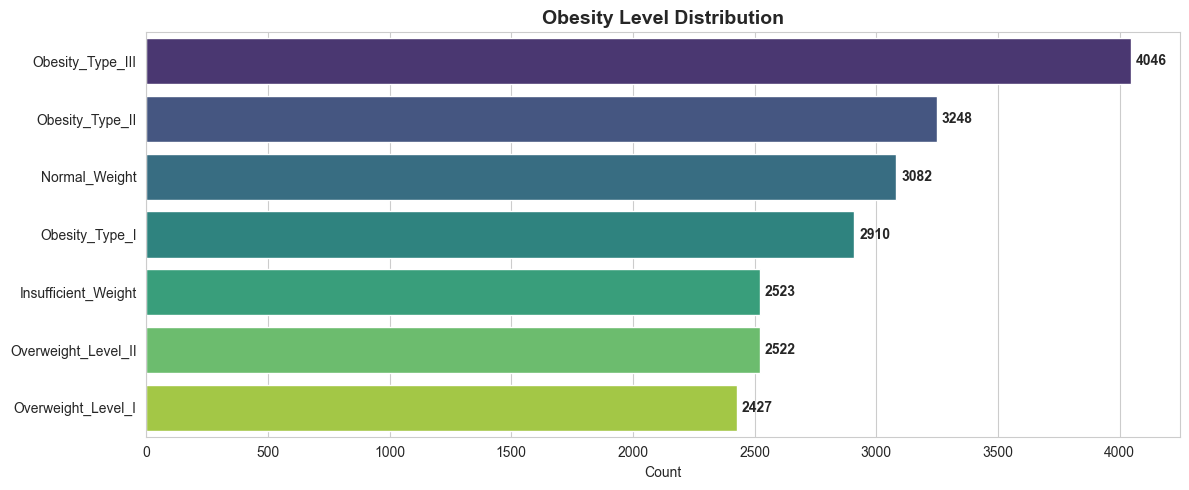

In [7]:
# Target distribution
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
order = df['Obesity_Level'].value_counts().index
sns.countplot(data=df, y='Obesity_Level', order=order, palette='viridis', ax=ax)
ax.set_title('Obesity Level Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Count')
ax.set_ylabel('')
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', (p.get_width() + 20, p.get_y() + p.get_height()/2),
                ha='left', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

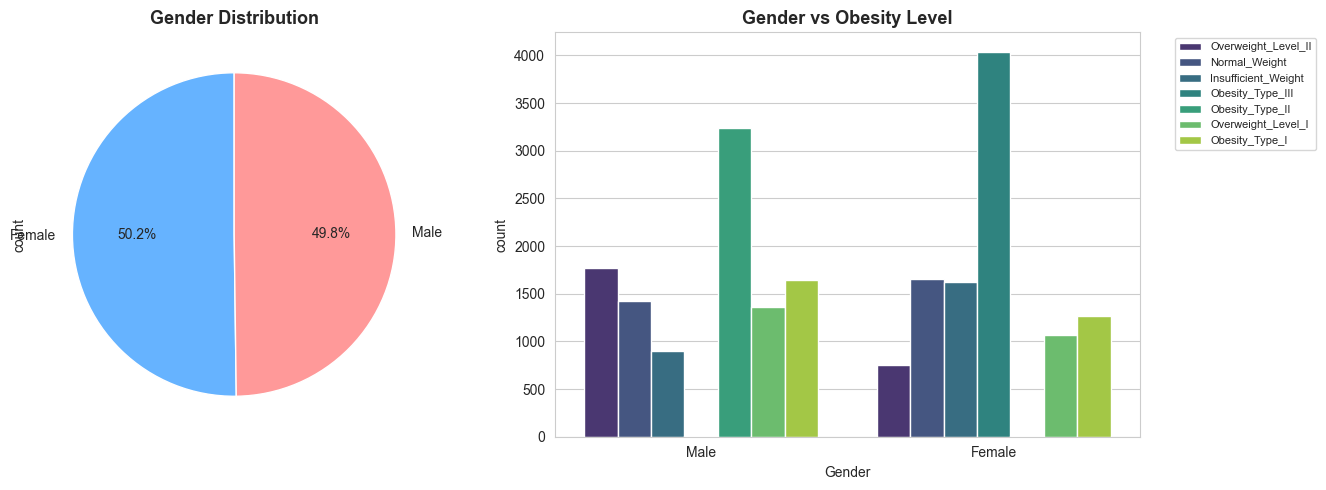

In [8]:
# Gender distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Gender'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999'],
                                      ax=axes[0], startangle=90)
axes[0].set_title('Gender Distribution', fontsize=13, fontweight='bold')

sns.countplot(data=df, x='Gender', hue='Obesity_Level', palette='viridis', ax=axes[1])
axes[1].set_title('Gender vs Obesity Level', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

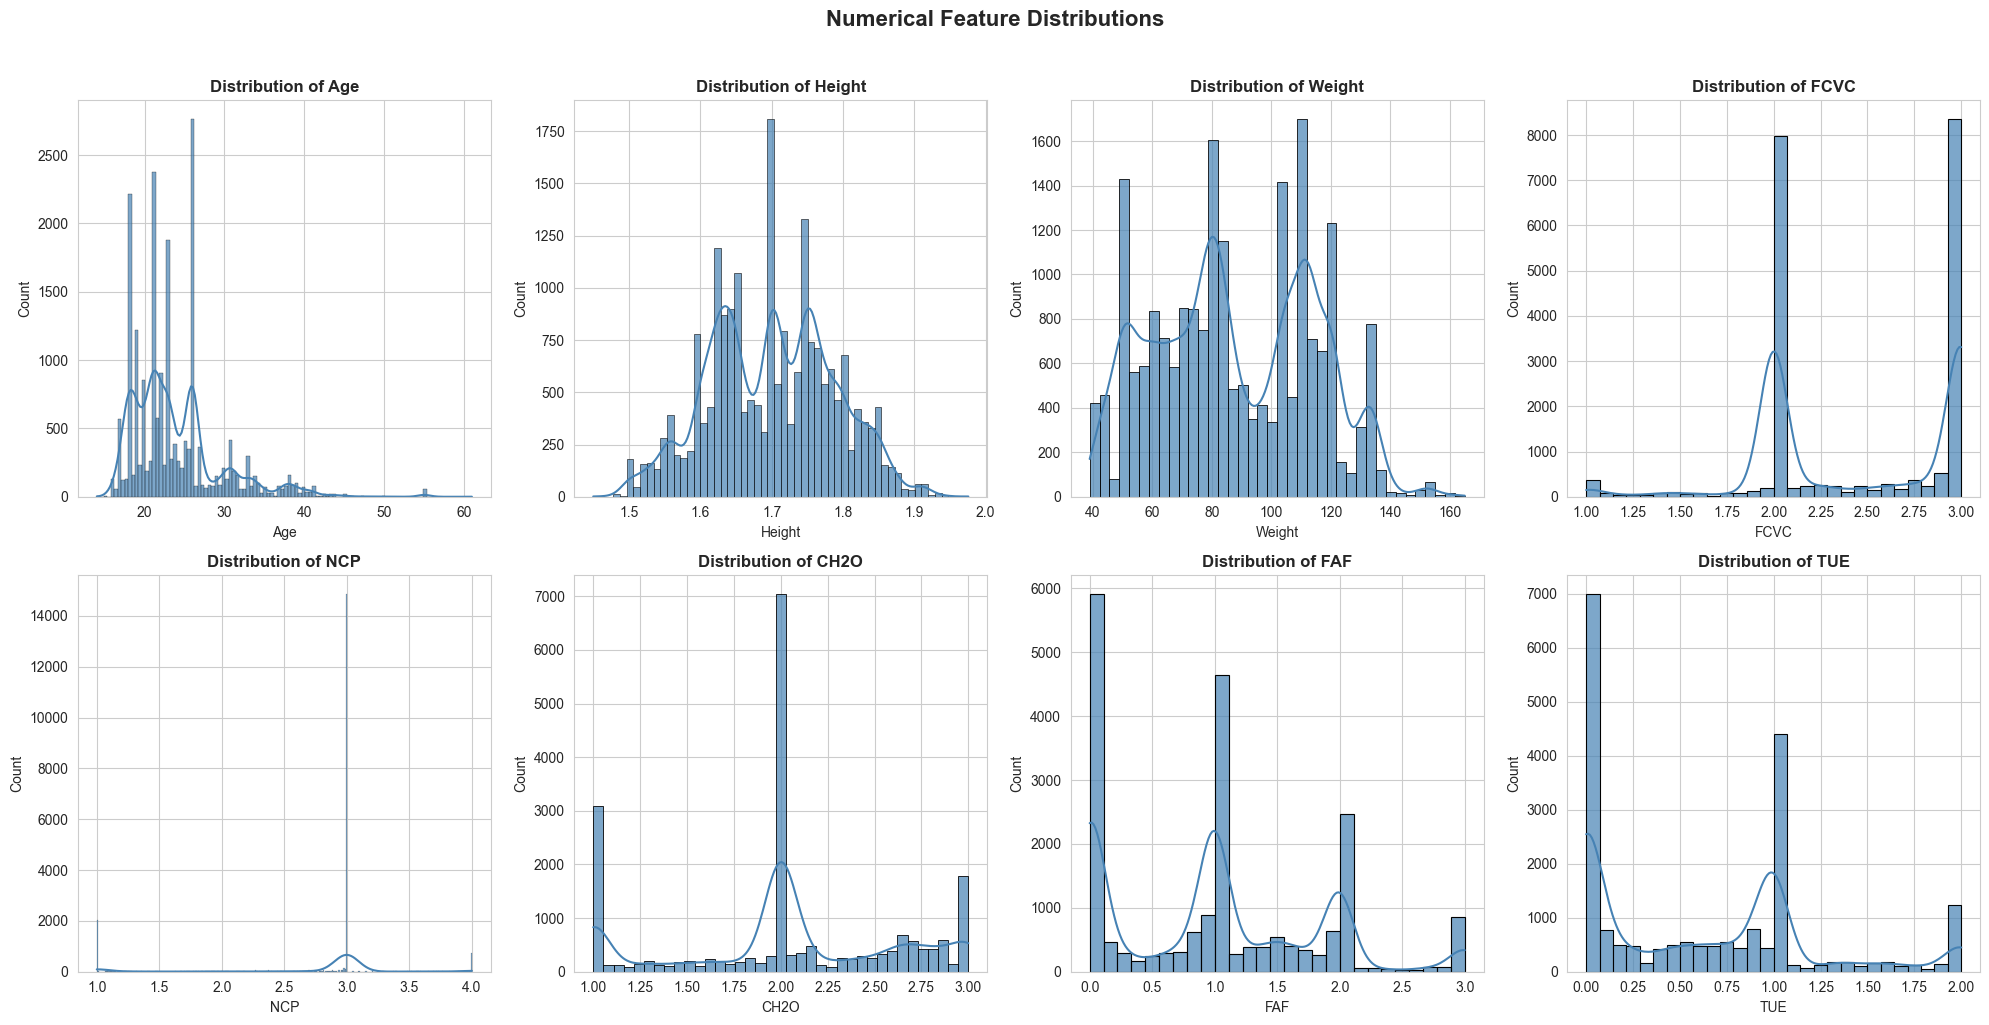

In [9]:
# Numerical feature distributions
num_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i, col in enumerate(num_cols):
    ax = axes[i//4, i%4]
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
plt.suptitle('Numerical Feature Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

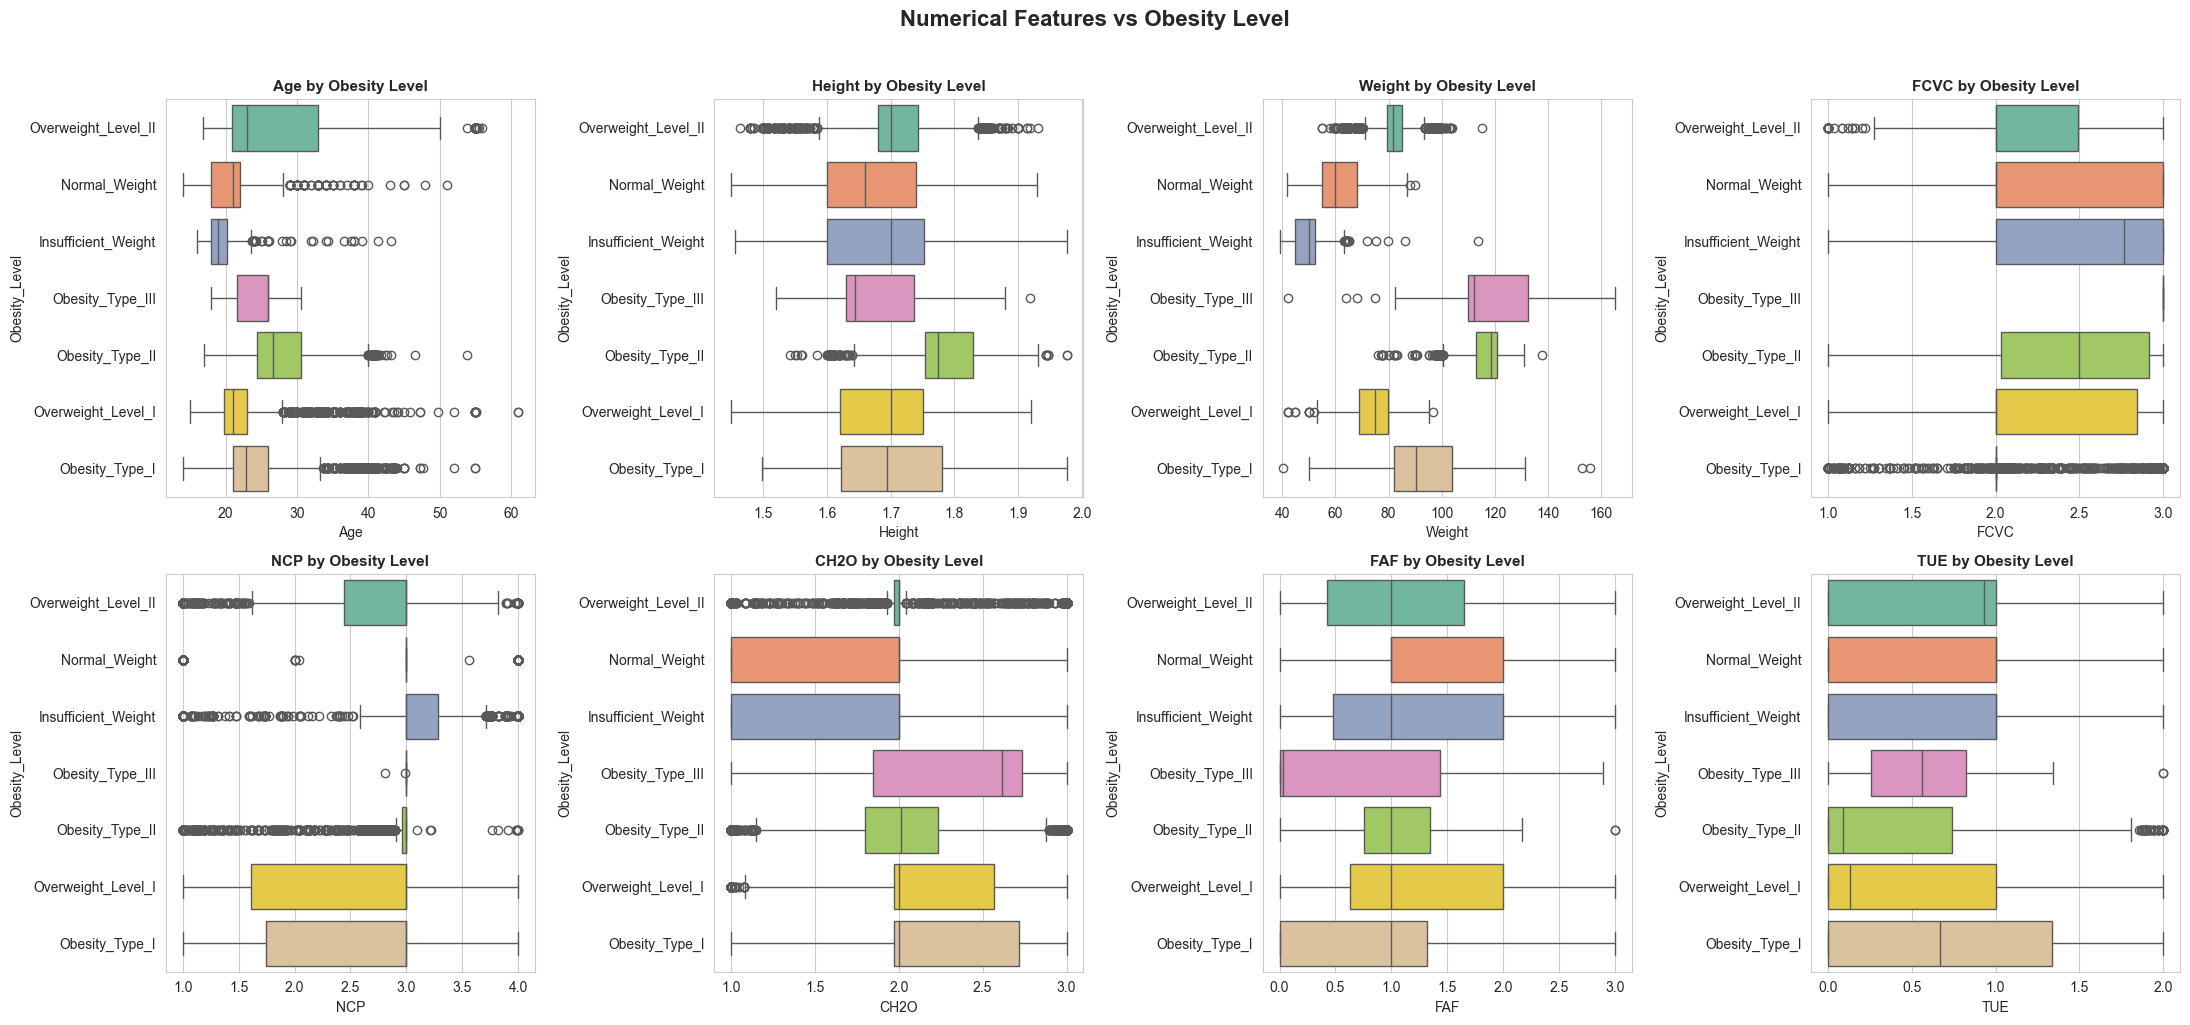

In [10]:
# Box plots of numerical features by obesity level
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
for i, col in enumerate(num_cols):
    ax = axes[i//4, i%4]
    sns.boxplot(data=df, y='Obesity_Level', x=col, palette='Set2', ax=ax)
    ax.set_title(f'{col} by Obesity Level', fontsize=11, fontweight='bold')
plt.suptitle('Numerical Features vs Obesity Level', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

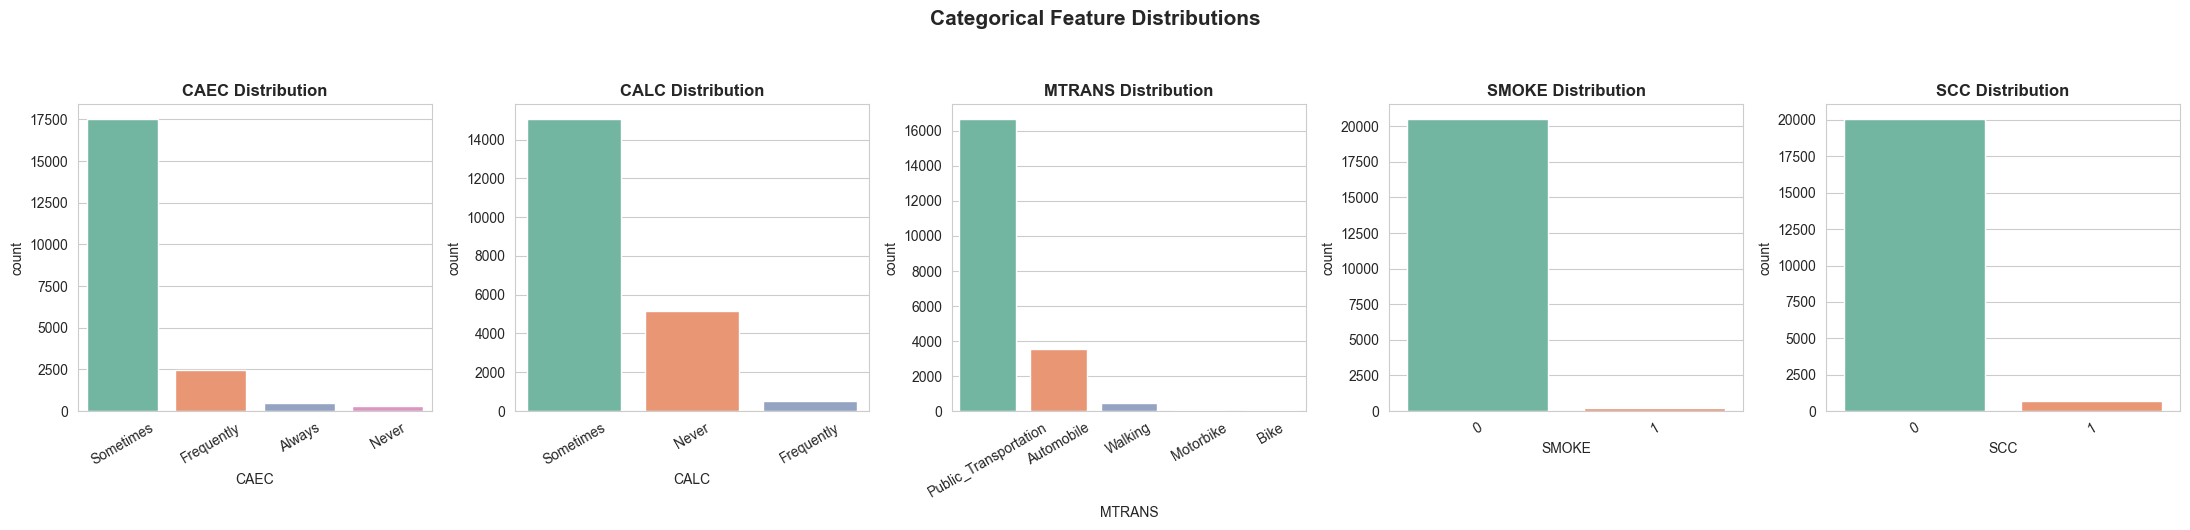

In [11]:
# Categorical features
cat_cols = ['CAEC', 'CALC', 'MTRANS', 'SMOKE', 'SCC']
fig, axes = plt.subplots(1, len(cat_cols), figsize=(22, 5))
for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, palette='Set2', ax=axes[i], order=df[col].value_counts().index)
    axes[i].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30)
plt.suptitle('Categorical Feature Distributions', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

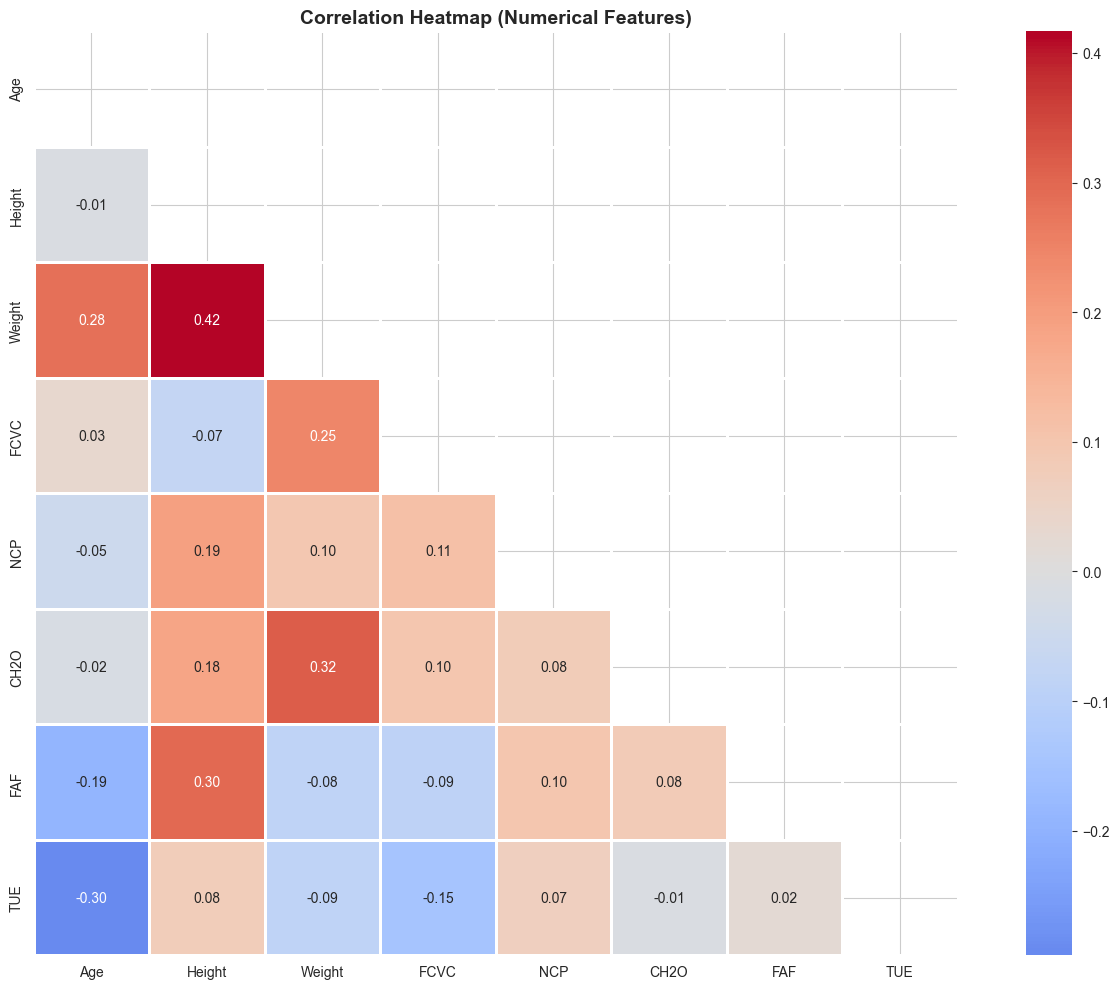

In [12]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(14, 10))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, square=True, linewidths=1, ax=ax)
ax.set_title('Correlation Heatmap (Numerical Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

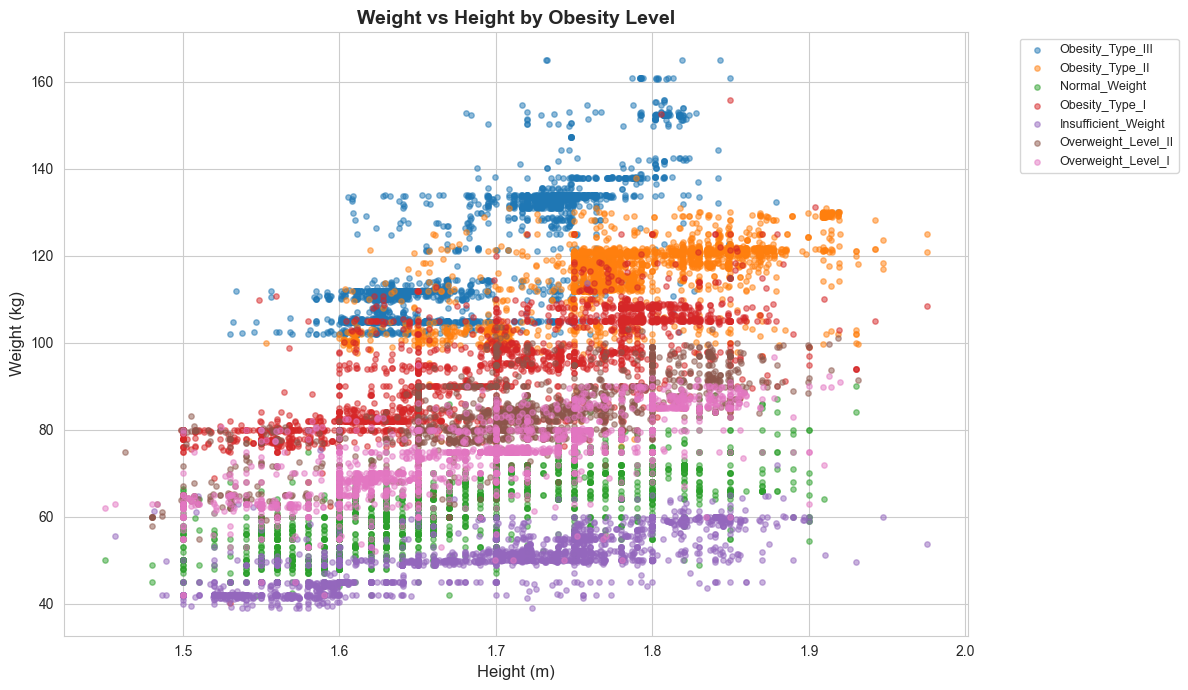

In [13]:
# Weight vs Height scatter plot colored by obesity level
fig, ax = plt.subplots(figsize=(12, 7))
palette = sns.color_palette('Set1', n_colors=df['Obesity_Level'].nunique())
order_labels = df['Obesity_Level'].value_counts().index.tolist()
for idx, level in enumerate(order_labels):
    subset = df[df['Obesity_Level'] == level]
    ax.scatter(subset['Height'], subset['Weight'], alpha=0.5, label=level, s=15)
ax.set_xlabel('Height (m)', fontsize=12)
ax.set_ylabel('Weight (kg)', fontsize=12)
ax.set_title('Weight vs Height by Obesity Level', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

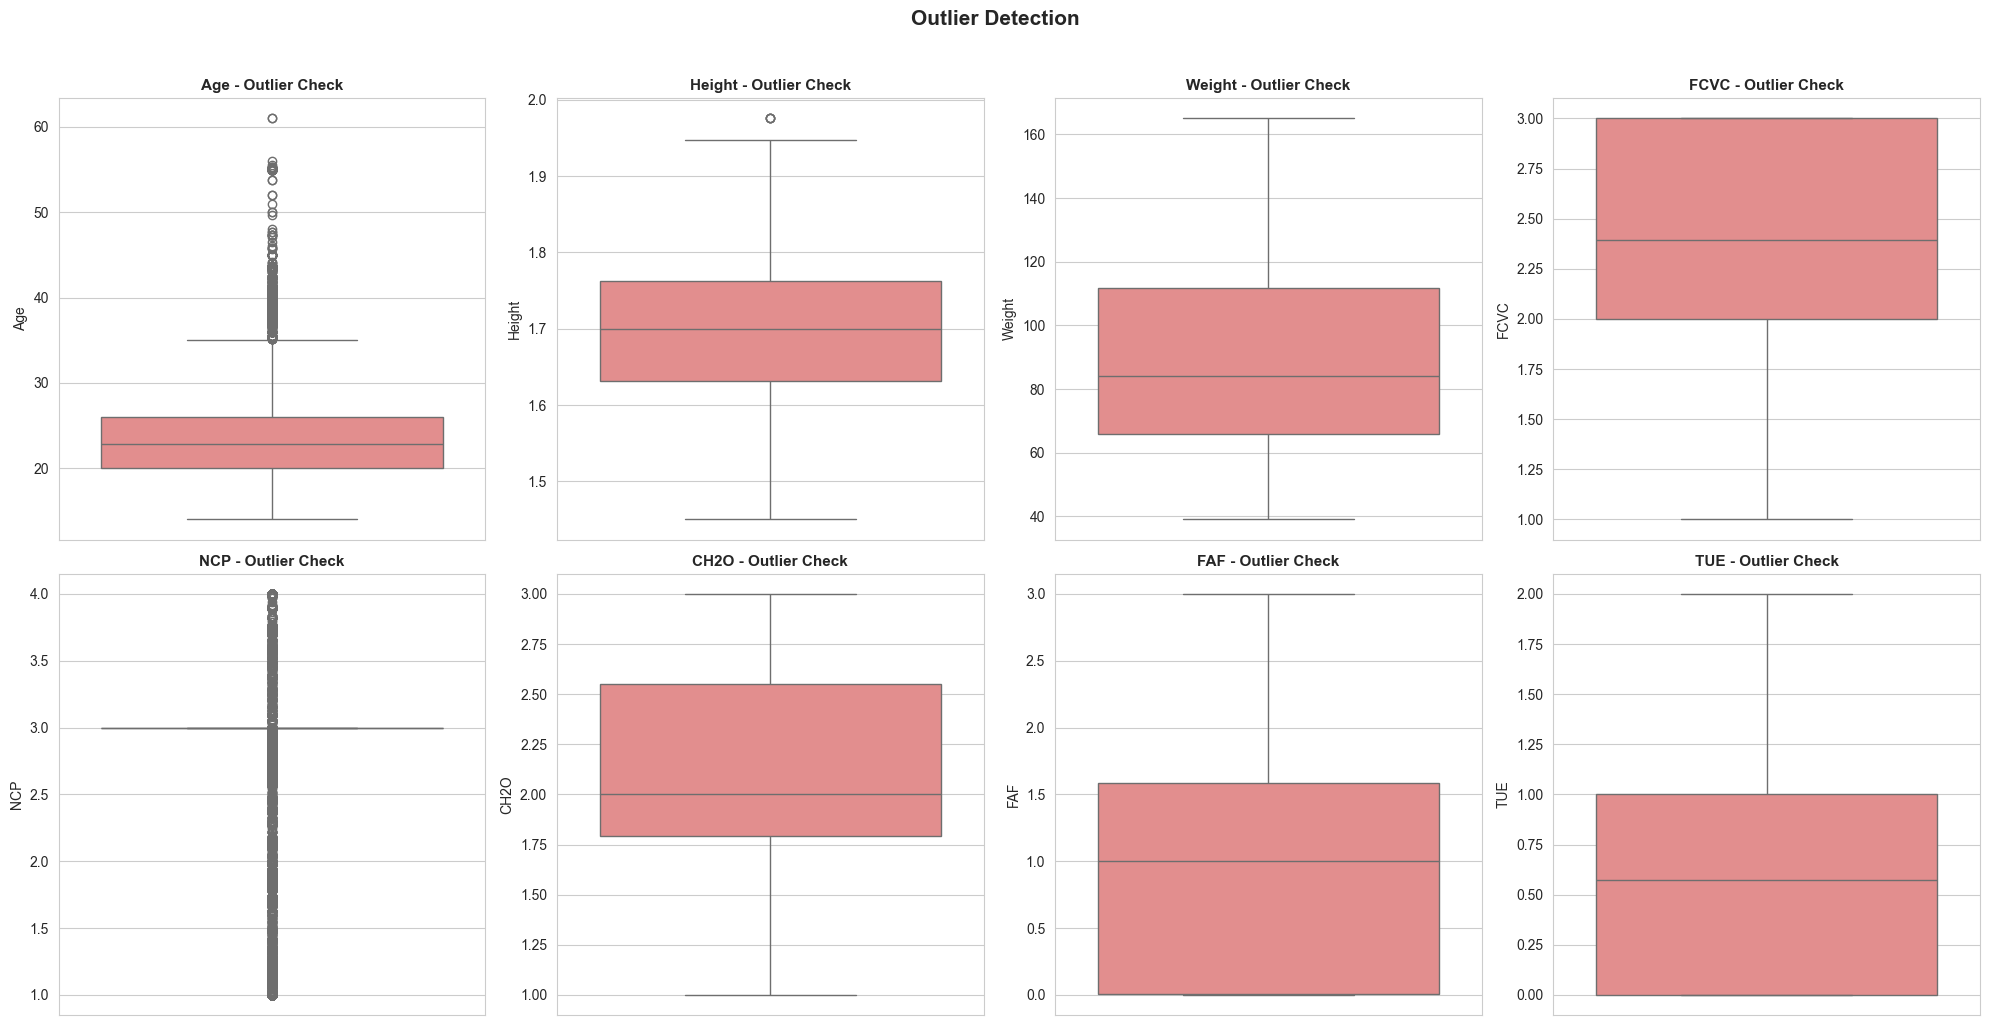

In [14]:
# Outlier detection with boxplots for all numerical features
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i, col in enumerate(num_cols):
    sns.boxplot(data=df[col], ax=axes[i//4, i%4], color='lightcoral')
    axes[i//4, i%4].set_title(f'{col} - Outlier Check', fontsize=11, fontweight='bold')
plt.suptitle('Outlier Detection', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Data Analysis Summary
- **No missing values** in the dataset (20758 rows x 18 cols)
- **Target classes** (7): fairly balanced distribution
- **Corrupted column names** (`0be1dad`, `0rmal_Weight`, `0`) have been fixed
- **Weight** is the strongest predictor correlated with obesity level
- **Age** and **Weight** show positive correlation
- **FAF** (physical activity) shows negative correlation with weight
- **CAEC** and **CALC** had `0` values meaning "Never" - corrected

## 4. Data Preprocessing & Cleaning

In [15]:
# Drop id column
df.drop('id', axis=1, inplace=True)
print(f'Shape after dropping id: {df.shape}')

Shape after dropping id: (20758, 17)


In [16]:
# Encode Gender
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

# Ordinal encode ordered categorical features
ordinal_mappings = {
    'CAEC': {'Never': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3},
    'CALC': {'Never': 0, 'Sometimes': 1, 'Frequently': 2}
}
for col, mapping in ordinal_mappings.items():
    df[col] = df[col].map(mapping)

# One-hot encode MTRANS
df = pd.get_dummies(df, columns=['MTRANS'], prefix='MTRANS', drop_first=True)

# Encode target
target_encoder = LabelEncoder()
df['Obesity_Level'] = target_encoder.fit_transform(df['Obesity_Level'])

print('Encoded classes:', target_encoder.classes_)
print(f'\nShape after encoding: {df.shape}')
df.head()

Encoded classes: ['Insufficient_Weight' 'Normal_Weight' 'Obesity_Type_I' 'Obesity_Type_II'
 'Obesity_Type_III' 'Overweight_Level_I' 'Overweight_Level_II']

Shape after encoding: (20758, 20)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,Obesity_Level,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,1,24.443011,1.699998,81.669950,1,1,2.000000,2.983297,1,0,2.763573,0,0.000000,0.976473,1,6,False,False,True,False
1,0,18.000000,1.560000,57.000000,1,1,2.000000,3.000000,2,0,2.000000,0,1.000000,1.000000,0,1,False,False,False,False
2,0,18.000000,1.711460,50.165754,1,1,1.880534,1.411685,1,0,1.910378,0,0.866045,1.673584,0,0,False,False,True,False
3,0,20.952737,1.710730,131.274851,1,1,3.000000,3.000000,1,0,1.674061,0,1.467863,0.780199,1,4,False,False,True,False
4,1,31.641081,1.914186,93.798055,1,1,2.679664,1.971472,1,0,1.979848,0,1.967973,0.931721,1,6,False,False,True,False


In [17]:
# Feature engineering - BMI
df['BMI'] = df['Weight'] / (df['Height'] ** 2)

# Age groups
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 18, 25, 35, 50, 100], labels=[0, 1, 2, 3, 4]).astype(float)

# Physical activity score
df['Activity_Score'] = df['FAF'] - df['TUE']

print('Feature engineering done. New features: BMI, Age_Group, Activity_Score')
print(f'Final shape: {df.shape}')

Feature engineering done. New features: BMI, Age_Group, Activity_Score
Final shape: (20758, 23)


In [18]:
# Separate features and target
X = df.drop('Obesity_Level', axis=1)
y = df['Obesity_Level']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

# Scale numerical features
scaler = StandardScaler()
num_features = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI', 'Age_Group', 'Activity_Score']
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

print('Scaling complete.')
X_train.head()

Train: (16606, 22), Test: (4152, 22)
Scaling complete.


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,...,FAF,TUE,CALC,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking,BMI,Age_Group,Activity_Score
4515,1,-0.324671,0.114410,0.080848,1,1,-0.838072,-2.478371,1,0,...,0.028876,2.297650,1,False,False,True,False,0.065043,-0.346270,-1.332665
7949,0,3.028261,-0.685698,-0.411159,1,1,1.039585,-2.478371,1,0,...,-1.167280,-1.024744,1,False,False,False,False,-0.192873,2.246812,-0.352035
20677,1,-1.030552,1.143120,-1.205940,1,1,-0.838072,1.753176,2,0,...,1.225032,0.636453,0,False,False,False,False,-1.553869,-1.642811,0.628596
18079,1,-1.030552,0.000109,-0.108385,1,1,-0.838072,0.342660,2,0,...,1.225032,0.636453,2,False,False,True,False,-0.098943,-1.642811,0.628596
5129,1,-0.194908,1.708053,1.278998,1,1,-0.176530,-0.080535,1,0,...,0.847743,0.203892,1,False,False,True,False,0.639672,-0.346270,0.574635


## 5. Model Building & Comparison

In [19]:
# Train multiple models and compare
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, use_label_encoder=False, eval_metric='mlogloss',
                              random_state=42, n_jobs=-1),
    'LightGBM': LGBMClassifier(n_estimators=200, random_state=42, n_jobs=-1, verbose=-1)
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    results[name] = {
        'Accuracy': acc,
        'F1_Score': f1,
        'CV_Mean': cv_scores.mean(),
        'CV_Std': cv_scores.std()
    }
    print(f'  Accuracy: {acc:.4f} | F1: {f1:.4f} | CV: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')

results_df = pd.DataFrame(results).T.sort_values('CV_Mean', ascending=False)
print('\n=== Model Comparison ===')
print(results_df.to_string())

Training Logistic Regression...
  Accuracy: 0.8646 | F1: 0.8634 | CV: 0.8605 (+/- 0.0044)
Training Random Forest...
  Accuracy: 0.9053 | F1: 0.9048 | CV: 0.8992 (+/- 0.0067)
Training Gradient Boosting...
  Accuracy: 0.9061 | F1: 0.9057 | CV: 0.9001 (+/- 0.0054)
Training XGBoost...
  Accuracy: 0.9082 | F1: 0.9081 | CV: 0.9014 (+/- 0.0036)
Training LightGBM...
  Accuracy: 0.9061 | F1: 0.9058 | CV: 0.9026 (+/- 0.0040)

=== Model Comparison ===
                     Accuracy  F1_Score   CV_Mean    CV_Std
LightGBM             0.906069  0.905771  0.902626  0.004033
XGBoost              0.908237  0.908082  0.901421  0.003621
Gradient Boosting    0.906069  0.905657  0.900096  0.005381
Random Forest        0.905347  0.904787  0.899193  0.006659
Logistic Regression  0.864644  0.863435  0.860533  0.004426


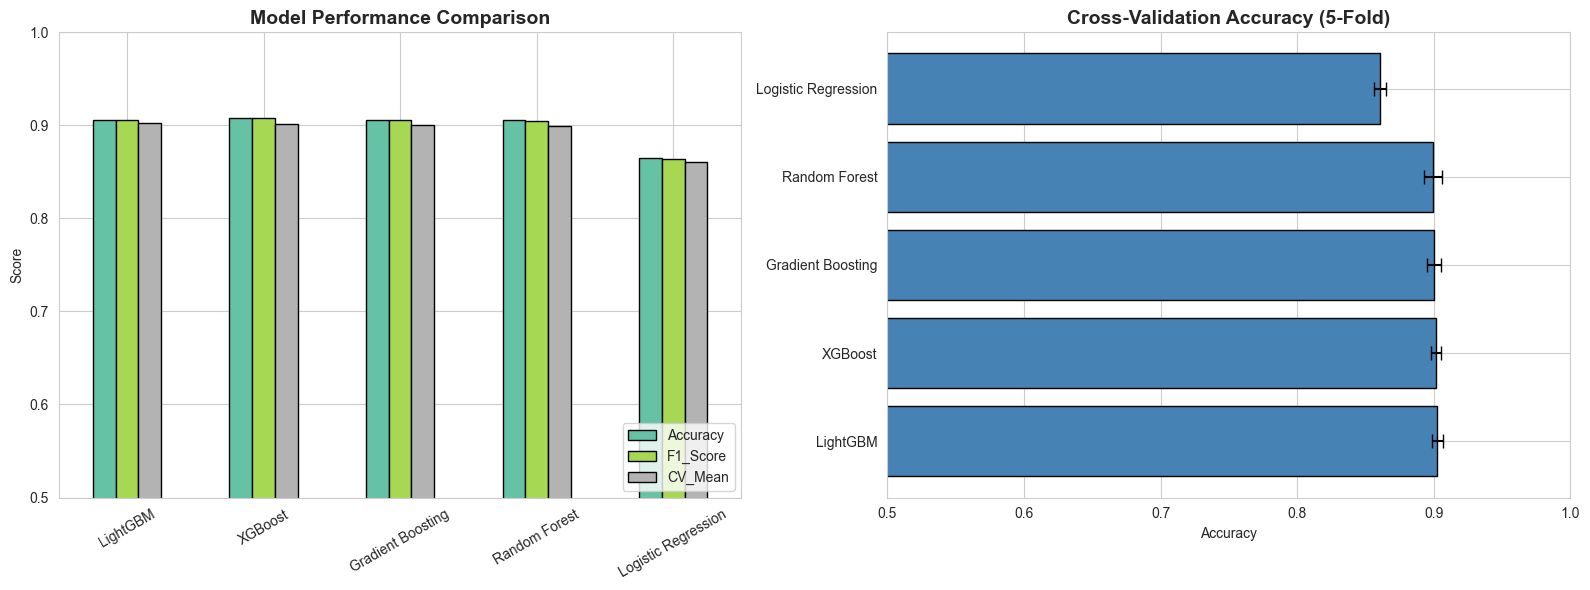

In [20]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

results_df[['Accuracy', 'F1_Score', 'CV_Mean']].plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='black')
axes[0].set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0.5, 1.0)
axes[0].legend(loc='lower right')
axes[0].tick_params(axis='x', rotation=30)

# CV scores with error bars
models_names = results_df.index.tolist()
cv_means = results_df['CV_Mean'].values
cv_stds = results_df['CV_Std'].values
axes[1].barh(models_names, cv_means, xerr=cv_stds, color='steelblue', edgecolor='black', capsize=5)
axes[1].set_title('Cross-Validation Accuracy (5-Fold)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Accuracy')
axes[1].set_xlim(0.5, 1.0)

plt.tight_layout()
plt.show()

In [21]:
# Best model detailed report
best_model_name = results_df.index[0]
print(f'Best Model: {best_model_name}')
print(f'CV Accuracy: {results_df.loc[best_model_name, "CV_Mean"]:.4f} (+/- {results_df.loc[best_model_name, "CV_Std"]:.4f})')
print()
best_pred = models[best_model_name].predict(X_test)
print(classification_report(y_test, best_pred, target_names=target_encoder.classes_))

Best Model: LightGBM
CV Accuracy: 0.9026 (+/- 0.0040)

                     precision    recall  f1-score   support

Insufficient_Weight       0.94      0.95      0.95       505
      Normal_Weight       0.88      0.89      0.89       617
     Obesity_Type_I       0.88      0.89      0.88       582
    Obesity_Type_II       0.97      0.97      0.97       650
   Obesity_Type_III       1.00      1.00      1.00       809
 Overweight_Level_I       0.80      0.77      0.78       485
Overweight_Level_II       0.81      0.80      0.81       504

           accuracy                           0.91      4152
          macro avg       0.90      0.90      0.90      4152
       weighted avg       0.91      0.91      0.91      4152



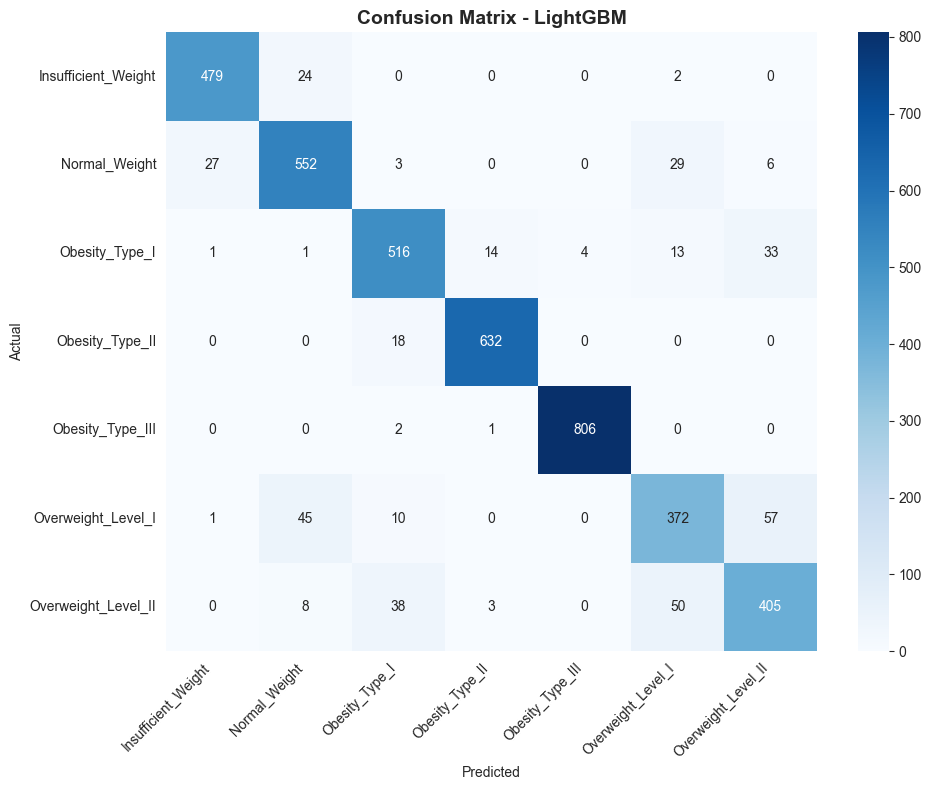

In [22]:
# Confusion matrix of best model
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_, ax=ax)
ax.set_title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Hyperparameter Tuning (RandomizedSearchCV + GridSearchCV)

In [ ]:
# RandomizedSearchCV on the top 3 models to find best hyperparameters
from scipy.stats import randint, uniform

param_grids = {
    'XGBoost': {
        'n_estimators': randint(200, 800),
        'max_depth': randint(3, 12),
        'learning_rate': uniform(0.01, 0.3),
        'subsample': uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4),
        'min_child_weight': randint(1, 10),
        'gamma': uniform(0, 0.5),
        'reg_alpha': uniform(0, 1),
        'reg_lambda': uniform(0, 1)
    },
    'LightGBM': {
        'n_estimators': randint(200, 800),
        'max_depth': randint(3, 15),
        'learning_rate': uniform(0.01, 0.3),
        'num_leaves': randint(20, 100),
        'subsample': uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4),
        'min_child_samples': randint(5, 50),
        'reg_alpha': uniform(0, 1),
        'reg_lambda': uniform(0, 1)
    },
    'Random Forest': {
        'n_estimators': randint(200, 800),
        'max_depth': randint(5, 30),
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 10),
        'max_features': ['sqrt', 'log2', None]
    }
}

model_instances = {
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42, n_jobs=-1),
    'LightGBM': LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1)
}

best_estimators = {}
for name in ['XGBoost', 'LightGBM', 'Random Forest']:
    print(f'\nRunning RandomizedSearchCV for {name}...')
    search = RandomizedSearchCV(
        model_instances[name],
        param_grids[name],
        n_iter=50,
        cv=cv,
        scoring='accuracy',
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    search.fit(X_train, y_train)
    best_estimators[name] = search.best_estimator_
    print(f'  Best params: {search.best_params_}')
    print(f'  Best CV Score: {search.best_score_:.4f}')
    test_acc = accuracy_score(y_test, search.best_estimator_.predict(X_test))
    print(f'  Test Accuracy: {test_acc:.4f}')


Running RandomizedSearchCV for XGBoost...
  Best params: {'colsample_bytree': np.float64(0.8075162486973464), 'gamma': np.float64(0.3515094794475889), 'learning_rate': np.float64(0.11908888071378819), 'max_depth': 3, 'min_child_weight': 4, 'n_estimators': 467, 'reg_alpha': np.float64(0.25178229582536416), 'reg_lambda': np.float64(0.49724850589238545), 'subsample': np.float64(0.7203513239267079)}
  Best CV Score: 0.9073
  Test Accuracy: 0.9111

Running RandomizedSearchCV for LightGBM...


In [ ]:
# GridSearchCV on the best model for fine-tuning
print('Running GridSearchCV on the top model for fine-tuning...')

# Get best model from RandomizedSearch
tuned_scores = {}
for name, est in best_estimators.items():
    scores = cross_val_score(est, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    tuned_scores[name] = {'CV_Mean': scores.mean(), 'CV_Std': scores.std()}
    test_acc = accuracy_score(y_test, est.predict(X_test))
    tuned_scores[name]['Test_Accuracy'] = test_acc
    print(f'{name}: CV={scores.mean():.4f} (+/- {scores.std():.4f}), Test={test_acc:.4f}')

best_tuned_name = max(tuned_scores, key=lambda x: tuned_scores[x]['CV_Mean'])
print(f'\nBest tuned model: {best_tuned_name}')

In [ ]:
# Fine-tune with GridSearchCV around best params
base_est = best_estimators[best_tuned_name]
print(f'Fine-tuning {best_tuned_name} with GridSearchCV...')

if best_tuned_name == 'XGBoost':
    grid_params = {
        'n_estimators': [base_est.n_estimators - 50, base_est.n_estimators, base_est.n_estimators + 50],
        'max_depth': [max(2, base_est.max_depth - 1), base_est.max_depth, base_est.max_depth + 1],
        'learning_rate': [max(0.01, base_est.learning_rate * 0.8), base_est.learning_rate, base_est.learning_rate * 1.2],
        'subsample': [min(1.0, max(0.5, base_est.subsample - 0.05)), base_est.subsample, min(1.0, base_est.subsample + 0.05)],
    }
elif best_tuned_name == 'LightGBM':
    grid_params = {
        'n_estimators': [base_est.n_estimators - 50, base_est.n_estimators, base_est.n_estimators + 50],
        'max_depth': [max(2, base_est.max_depth - 1), base_est.max_depth, base_est.max_depth + 1],
        'learning_rate': [max(0.01, base_est.learning_rate * 0.8), base_est.learning_rate, base_est.learning_rate * 1.2],
        'num_leaves': [max(15, base_est.num_leaves - 10), base_est.num_leaves, base_est.num_leaves + 10],
    }
else:
    grid_params = {
        'n_estimators': [base_est.n_estimators - 50, base_est.n_estimators, base_est.n_estimators + 50],
        'max_depth': [max(3, base_est.max_depth - 2), base_est.max_depth, base_est.max_depth + 2],
        'min_samples_split': [max(2, base_est.min_samples_split - 1), base_est.min_samples_split, base_est.min_samples_split + 1],
        'min_samples_leaf': [max(1, base_est.min_samples_leaf - 1), base_est.min_samples_leaf, base_est.min_samples_leaf + 1],
    }

grid_search = GridSearchCV(
    base_est,
    grid_params,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train, y_train)

print(f'GridSearch best params: {grid_search.best_params_}')
print(f'GridSearch best CV score: {grid_search.best_score_:.4f}')
test_acc = accuracy_score(y_test, grid_search.best_estimator_.predict(X_test))
print(f'GridSearch test accuracy: {test_acc:.4f}')

final_model = grid_search.best_estimator_

In [ ]:
# Ensemble - Voting Classifier with top 3 tuned models
print('Building Voting Classifier ensemble...')

# Sort tuned models by CV score
sorted_models = sorted(tuned_scores.items(), key=lambda x: x[1]['CV_Mean'], reverse=True)
top3_names = [m[0] for m in sorted_models[:3]]

estimators = []
for name in top3_names:
    estimators.append((name.lower().replace(' ', '_'), best_estimators[name]))

voting_clf = VotingClassifier(estimators=estimators, voting='hard', n_jobs=-1)
voting_clf.fit(X_train, y_train)
voting_pred = voting_clf.predict(X_test)
voting_acc = accuracy_score(y_test, voting_pred)
voting_f1 = f1_score(y_test, voting_pred, average='weighted')

print(f'Ensemble Test Accuracy: {voting_acc:.4f}')
print(f'Ensemble F1 Score: {voting_f1:.4f}')

In [ ]:
# Final model selection - pick the best among GridSearch result and Ensemble
final_pred = final_model.predict(X_test)
final_acc = accuracy_score(y_test, final_pred)
final_f1 = f1_score(y_test, final_pred, average='weighted')

print(f'GridSearch Model - Accuracy: {final_acc:.4f}, F1: {final_f1:.4f}')
print(f'Ensemble Model   - Accuracy: {voting_acc:.4f}, F1: {voting_f1:.4f}')

if voting_acc >= final_acc:
    print('\n>>> Selecting ENSEMBLE as final model')
    export_model = voting_clf
else:
    print(f'\n>>> Selecting {best_tuned_name} (GridSearch) as final model')
    export_model = final_model

In [ ]:
# Final model - detailed classification report
final_predictions = export_model.predict(X_test)
print('=== FINAL MODEL CLASSIFICATION REPORT ===')
print(f'Accuracy: {accuracy_score(y_test, final_predictions):.4f}')
print(f'F1 (weighted): {f1_score(y_test, final_predictions, average="weighted"):.4f}')
print()
print(classification_report(y_test, final_predictions, target_names=target_encoder.classes_))

In [ ]:
# Final confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, final_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_, ax=ax)
ax.set_title('Final Model - Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Export Model with Joblib

In [ ]:
# Save the final model and preprocessing artifacts
artifacts = {
    'model': export_model,
    'scaler': scaler,
    'target_encoder': target_encoder,
    'num_features': num_features,
    'feature_columns': X.columns.tolist()
}

joblib.dump(artifacts, 'obesity_model.pkl')
print('Model saved as obesity_model.pkl')

# Verify the saved model
loaded = joblib.load('obesity_model.pkl')
loaded_model = loaded['model']
verify_pred = loaded_model.predict(X_test)
verify_acc = accuracy_score(y_test, verify_pred)
print(f'Verification accuracy after loading: {verify_acc:.4f}')
print(f'Model type: {type(loaded_model).__name__}')
print(f'File size: {__import__("os").path.getsize("obesity_model.pkl") / (1024*1024):.2f} MB')

In [ ]:
# Quick prediction test
sample_idx = 0
sample = X_test.iloc[[sample_idx]]
prediction = loaded_model.predict(sample)
actual = y_test.iloc[sample_idx]

print(f'Predicted: {target_encoder.classes_[prediction[0]]}')
print(f'Actual:    {target_encoder.classes_[actual]}')
print(f'Match: {"YES" if prediction[0] == actual else "NO"}')